# Variational Autoencoders (VAEs)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision as tv
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [21]:
# Configuración de modelo
batch_size = 32
latent_dim = 256
device = "cuda:0"

In [22]:
# Preparación de dataset
mnist_mean = (0.1307,)
mnist_std = (0.3081,)

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

train_dataset = tv.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [23]:
# Definición de modelo
class VAE_MNIST(nn.Module):
  def __init__(self, latent_dim=latent_dim) -> None:
    super(VAE_MNIST, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2),

        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),

        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),

        nn.Flatten()
    )
    self.encoder_mu = nn.Sequential(
        nn.Linear(128*4*4, 128*4),
        nn.LeakyReLU(0.2),
        nn.Linear(128*4, latent_dim)
    )
    self.encoder_logvar = nn.Sequential(
        nn.Linear(128*4*4, 128*4),
        nn.LeakyReLU(0.2),
        nn.Linear(128*4, latent_dim)
    )
    self.decoder_input = nn.Linear(latent_dim, 128*4*4)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),

        nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2),

        nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=3, output_padding=1),
        nn.Tanh()
    )

  def reparametrize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    x = self.encoder(x)
    mu = self.encoder_mu(x)
    logvar = self.encoder_logvar(x)
    z = self.reparametrize(mu, logvar)
    z = self.decoder_input(z)
    z = z.view(-1, 128, 4, 4)
    x_hat = self.decoder(z)
    return x_hat, mu, logvar

In [24]:
# Definimos la función de pérdida
def vae_loss_function(x_hat, x, mu, logvar):
  reconstruction_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return reconstruction_loss + kl_loss

In [25]:
# Inicialización de modelo, optimizador y hardware
device = torch.device(device)
model = VAE_MNIST(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [26]:
# Entrenamiento
num_epochs = 15
model.train()
print(f'Empezando entrenamiendo por {num_epochs} epochs en MNIST en {device}...')

for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

print('Entrenamiento completado')

Empezando entrenamiendo por 15 epochs en MNIST en cuda:0...
Epoch [1/15], Average Loss: 377.7663
Epoch [2/15], Average Loss: 333.9969
Epoch [3/15], Average Loss: 326.9142
Epoch [4/15], Average Loss: 323.7295
Epoch [5/15], Average Loss: 321.6368
Epoch [6/15], Average Loss: 320.1159
Epoch [7/15], Average Loss: 318.9775
Epoch [8/15], Average Loss: 318.0771
Epoch [9/15], Average Loss: 317.3592
Epoch [10/15], Average Loss: 316.6943
Epoch [11/15], Average Loss: 316.1560
Epoch [12/15], Average Loss: 315.7040
Epoch [13/15], Average Loss: 315.2831
Epoch [14/15], Average Loss: 314.9197
Epoch [15/15], Average Loss: 314.5503
Entrenamiento completado


In [27]:
# Guardamos el modelo
torch.save(model.state_dict(), "vae_mnist.pth")

In [28]:
def denormalize_mnist(tensor):
    mean = torch.tensor(mnist_mean).view(1, 1, 1).to(device)
    std = torch.tensor(mnist_std).view(1, 1, 1).to(device)
    return torch.clamp((tensor * std) + mean, 0, 1)

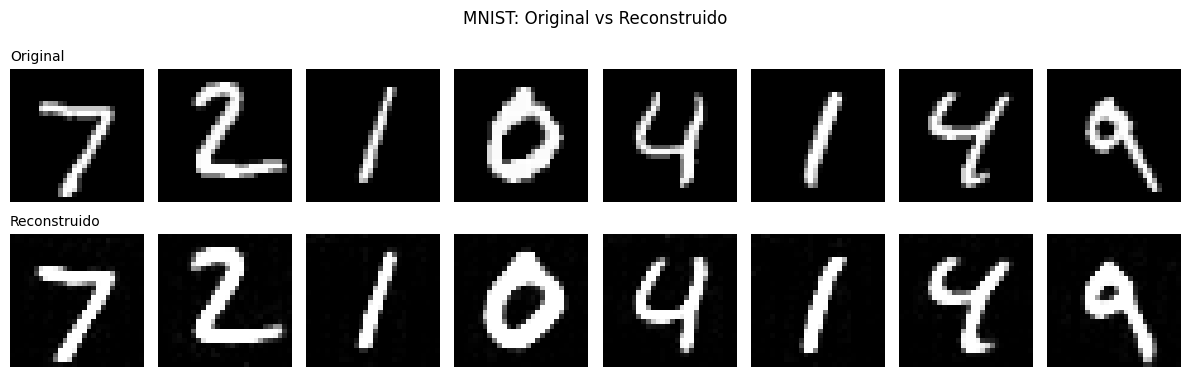

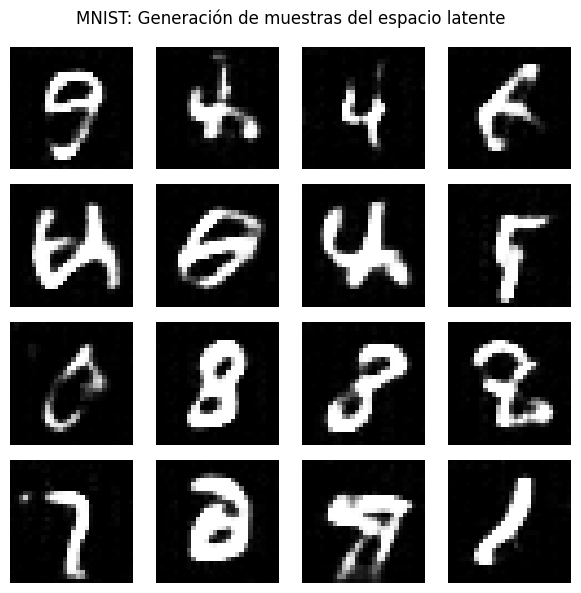

In [33]:
# Cargamos el modelo entrenado
model = VAE_MNIST(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('vae_mnist.pth', map_location=device))
model.eval()

with torch.no_grad():
    # Reconstrucción
    test_loader_viz = DataLoader(
        tv.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist),
        batch_size=8, shuffle=False
    )
    images, _ = next(iter(test_loader_viz))
    images = images.to(device)
    recon, _, _ = model(images)

    images_denorm = denormalize_mnist(images).cpu()
    recon_denorm  = denormalize_mnist(recon).cpu()

    fig, axes = plt.subplots(2, 8, figsize=(12, 4))
    for i in range(8):
        axes[0, i].imshow(images_denorm[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_denorm[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_title('Original', fontsize=10, loc='left')
    axes[1, 0].set_title('Reconstruido', fontsize=10, loc='left')
    plt.suptitle('MNIST: Original vs Reconstruido', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Generación de muestras
    latent_samples = torch.randn(16, model.latent_dim).to(device)
    gen_input = model.decoder_input(latent_samples).view(-1, 128, 4, 4)
    generated = denormalize_mnist(model.decoder(gen_input)).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('MNIST: Generación de muestras del espacio latente', fontsize=12)
    plt.tight_layout()
    plt.show()

#### Why Are Denoising Diffusion Probabilistic Models (DDPM) Necessary?

While VAEs are powerful generative models, they have fundamental limitations that motivated the development of diffusion models:

VAEs typically use MSE loss, which averages over all possible outputs. This leads to blurry images because the model hedges between multiple plausible reconstructions. The decoder learns to output the mean of the conditional distribution p(x|z), rather than sampling from it.

They also assume the posterior q(z|x) is Gaussian (or another simple distribution). This restriction may not capture complex, multimodal posteriors that exist in real data, limiting the model's ability to encode rich information.

#### How DDPMs Address These Issues:

**Iterative Refinement:** DDPMs generate images through a gradual denoising process over many steps (e.g., 1000 timesteps). This allows the model to progressively add details, resulting in sharper, higher-quality images.

**No Posterior Collapse:** DDPMs don't have an encoder during generation—they use a fixed forward diffusion process. This avoids the posterior collapse problem where the latent space becomes uninformative.

### Trade-offs:

DDPMs are **much slower** at generation time (100-1000 forward passes vs 1 for VAEs) but achieve superior image quality. Recent advances like DDIM sampling and latent diffusion models (which combine VAEs with diffusion in latent space) aim to get the best of both worlds.

**Key Takeaway:** VAEs compress data into a low-dimensional bottleneck, while diffusion models learn to reverse a gradual corruption process. The latter provides more flexibility and better captures the complexity of high-dimensional data distributions.